In [1]:
# from __future__ import annotations

import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from typing import Tuple
import random

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


class SimpleCNN(nn.Module):

    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


@dataclass
class WatermarkKey:
    bits: torch.Tensor
    X: torch.Tensor


class UchidaWatermarker:

    def __init__(
        self,
        target_layer: nn.Conv2d,
        num_bits: int,
        device: torch.device,
        seed: int = 42,
    ) -> None:
        self.layer = target_layer
        self.num_bits = num_bits
        self.device = device

        g = torch.Generator(device="cpu")
        g.manual_seed(seed)

        _, in_c, k_h, k_w = self.layer.weight.shape
        self.M = in_c * k_h * k_w

        bits = torch.randint(0, 2, (num_bits,), generator=g, dtype=torch.float32)
        X = torch.randn(num_bits, self.M, generator=g, dtype=torch.float32)

        self.key = WatermarkKey(bits=bits.to(device), X=X.to(device))

    def mean_weight_vector(self) -> torch.Tensor:
        w = self.layer.weight  # [L, D, S, S]
        w_mean = w.mean(dim=0).reshape(-1)  # [M]
        return w_mean

    def embedding_logits(self) -> torch.Tensor:
        w_vec = self.mean_weight_vector()
        return self.key.X @ w_vec

    def embedding_loss(self) -> torch.Tensor:
        logits = self.embedding_logits()
        return F.binary_cross_entropy_with_logits(logits, self.key.bits)

    @torch.no_grad()
    def extract_bits(self) -> torch.Tensor:
        logits = self.embedding_logits()
        return (logits >= 0).float()

    @torch.no_grad()
    def bit_error_rate(self) -> float:
        pred = self.extract_bits()
        ber = (pred != self.key.bits).float().mean().item()
        return ber

    @torch.no_grad()
    def confidence(self) -> float:
        probs = torch.sigmoid(self.embedding_logits())
        return probs.mean().item()

def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_dataloaders(
    data_root: str,
    batch_size: int,
    download: bool,
    train_fraction: float = 1.0,
    test_fraction: float = 1.0,
    seed: int = 42,
) -> Tuple[DataLoader, DataLoader]:
    train_t = transforms.Compose(
        [
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ]
    )
    test_t = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ]
    )

    train_ds = datasets.CIFAR10(
        data_root,
        train=True,
        transform=train_t,
        download=download,
    )
    test_ds = datasets.CIFAR10(
        data_root,
        train=False,
        transform=test_t,
        download=download,
    )

    if not (0 < train_fraction <= 1.0):
        raise ValueError("train_fraction must be in (0, 1].")
    if not (0 < test_fraction <= 1.0):
        raise ValueError("test_fraction must be in (0, 1].")

    rng = random.Random(seed)

    if train_fraction < 1.0:
        train_size = int(len(train_ds) * train_fraction)
        train_indices = list(range(len(train_ds)))
        rng.shuffle(train_indices)
        train_ds = Subset(train_ds, train_indices[:train_size])

    if test_fraction < 1.0:
        test_size = int(len(test_ds) * test_fraction)
        test_indices = list(range(len(test_ds)))
        rng.shuffle(test_indices)
        test_ds = Subset(test_ds, test_indices[:test_size])

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, test_loader

def compute_ce_loss(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> float:
    model.eval()
    total_ce = 0.0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            ce = F.cross_entropy(logits, y)

            bs = y.size(0)
            total_ce += ce.item() * bs
            total += bs

    return total_ce / max(1, total)

def evaluate_accuracy(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()
    return 100.0 * correct / max(1, total)


def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    watermarker: UchidaWatermarker,
    lambda_wm: float,
) -> Dict[str, float]:
    model.train()
    total_ce = 0.0
    total_wm = 0.0
    total = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        ce = F.cross_entropy(logits, y)

        wm_loss = torch.tensor(0.0, device=device)
        if watermarker is not None and lambda_wm > 0.0:
            wm_loss = watermarker.embedding_loss()

        loss = ce + lambda_wm * wm_loss
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_ce += ce.item() * bs
        total_wm += wm_loss.item() * bs
        total += bs

    return {
        "train_ce_loss": total_ce / max(1, total),
        "val_ce_loss": compute_ce_loss(model, val_loader, device),
        "wm_loss": total_wm / max(1, total),
    }


def save_key(key: WatermarkKey, out_path: Path) -> None:
    payload = {
        "bits": key.bits.detach().cpu(),
        "X": key.X.detach().cpu(),
    }
    torch.save(payload, out_path)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
seed = 42
set_seed(seed)
device = torch.device('cuda')

out_dir = Path('drive/MyDrive/Security-Project/water_marked_lambda=0.6')
out_dir.mkdir(parents=True, exist_ok=True)
data_root = './data'

epochs = 9
fine_tune_epochs = 5

batch_size = 128
download = True
num_bits = 256

lr = 1e-3
# lambda_wm = 0.00
lambda_wm = 0.6

ds_fraction = 1.0

config = {
    "train_epochs": epochs,
    "fine_tune_epochs": fine_tune_epochs,
    "batch_size": batch_size,
    "lr": lr,
    "lambda_wm": lambda_wm,
    "dataset_fraction": ds_fraction,
    "num_bits": num_bits
}

train_loader, val_loader = get_dataloaders(
    data_root=data_root,
    batch_size=batch_size,
    download=download,
    train_fraction=ds_fraction,
    test_fraction=ds_fraction
)

model = SimpleCNN(num_classes=10).to(device)
target_conv = model.features[2]
watermarker = UchidaWatermarker(
    target_layer=target_conv,
    num_bits=num_bits,
    device=device,
    seed=seed,
)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

history: List[Dict[str, float]] = []

print(f"Training started for {epochs} epochs ...")
for epoch in range(1, epochs + 1):
    train_stats = train_epoch(model, train_loader, val_loader, optimizer, device, watermarker=watermarker, lambda_wm=lambda_wm)
    acc = evaluate_accuracy(model, val_loader, device)
    ber = watermarker.bit_error_rate()
    wm_conf = watermarker.confidence()

    row = {
        "epoch": epoch,
        "test_acc": acc,
        "train_ce_loss": train_stats["train_ce_loss"],
        "val_ce_loss": train_stats["val_ce_loss"],
        "wm_loss": train_stats["wm_loss"],
        "ber": ber,
        "wm_conf": wm_conf,
    }
    history.append(row)
    print(
        f"[train] epoch={epoch:03d} acc={acc:.2f}% "
        f"train_ce={row['train_ce_loss']:.4f} val_ce={row['val_ce_loss']:.4f} wm={row['wm_loss']:.4f} ber={ber:.4f}"
    )

fine_tune_history: List[Dict[str, float]] = []
if fine_tune_epochs > 0:
    print(f"Fine Tuning started for {fine_tune_epochs} epochs ...")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, fine_tune_epochs + 1):
        stats = train_epoch(model, train_loader, val_loader, optimizer, device, watermarker, 0.0)
        acc = evaluate_accuracy(model, val_loader, device)
        ber = watermarker.bit_error_rate()
        row = {
            "epoch": epoch,
            "test_acc": acc,
            "train_ce_loss": train_stats["train_ce_loss"],
            "val_ce_loss": train_stats["val_ce_loss"],
            "wm_loss": train_stats["wm_loss"],
            "ber": ber,
            "wm_conf": wm_conf,
        }
        fine_tune_history.append(row)
        print(
            f"[fine-tune] epoch={epoch:03d} acc={acc:.2f}% "
            f"train_ce={stats['train_ce_loss']:.4f} val_ce={stats['val_ce_loss']:.4f} wm={stats['wm_loss']:.4f} ber={ber:.4f}"
        )

ckpt_path = out_dir / "model.pt"
key_path = out_dir / "watermark_key.pt"
hist_path = out_dir / "history.json"
config_path = out_dir / "config.json"
fine_tune_hist_path = out_dir / "fine_tune_history.json"

torch.save(model.state_dict(), ckpt_path)
save_key(watermarker.key, key_path)
hist_path.write_text(json.dumps(history, indent=4), encoding='utf-8')
config_path.write_text(json.dumps(config, indent=4), encoding='utf-8')
if fine_tune_epochs > 0:
    fine_tune_hist_path.write_text(json.dumps(fine_tune_history, indent=4), encoding='utf-8')

print(f"{'Saved model:':<14} {ckpt_path}")
print(f"{'Saved key:':<14} {key_path}")
print(f"{'Saved tr_log:':<14} {hist_path}")
print(f"{'Saved ft_log:':<14} {fine_tune_hist_path}")
print(f"{'Saved config:':<14} {config_path}")

Training started for 9 epochs ...
[train] epoch=001 acc=60.88% train_ce=1.5346 val_ce=1.0901 wm=0.3810 ber=0.0039
[train] epoch=002 acc=68.54% train_ce=1.0772 val_ce=0.8909 wm=0.1861 ber=0.0000
[train] epoch=003 acc=72.77% train_ce=0.9176 val_ce=0.7769 wm=0.1228 ber=0.0000
[train] epoch=004 acc=75.86% train_ce=0.8290 val_ce=0.6948 wm=0.0897 ber=0.0000
[train] epoch=005 acc=76.17% train_ce=0.7532 val_ce=0.6926 wm=0.0698 ber=0.0000
[train] epoch=006 acc=77.72% train_ce=0.7141 val_ce=0.6295 wm=0.0566 ber=0.0000
[train] epoch=007 acc=79.03% train_ce=0.6767 val_ce=0.5932 wm=0.0473 ber=0.0000


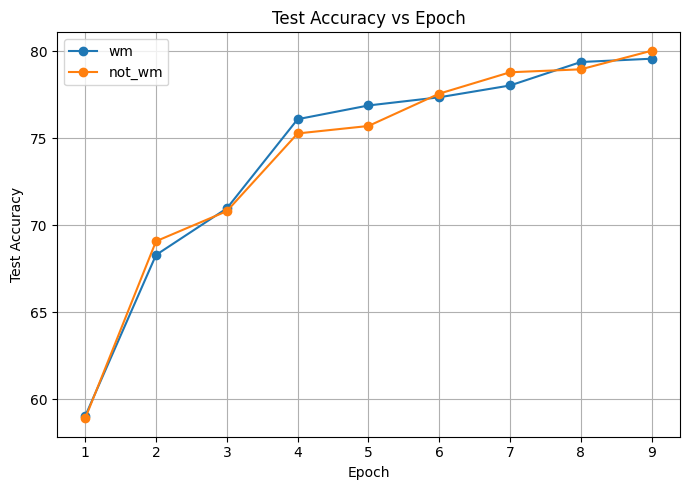

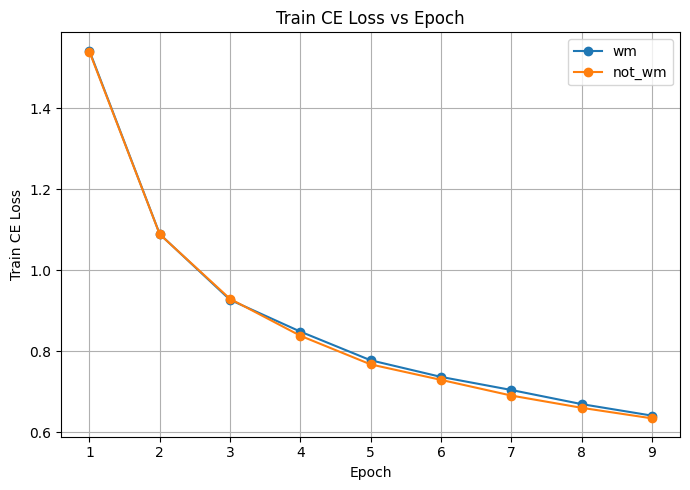

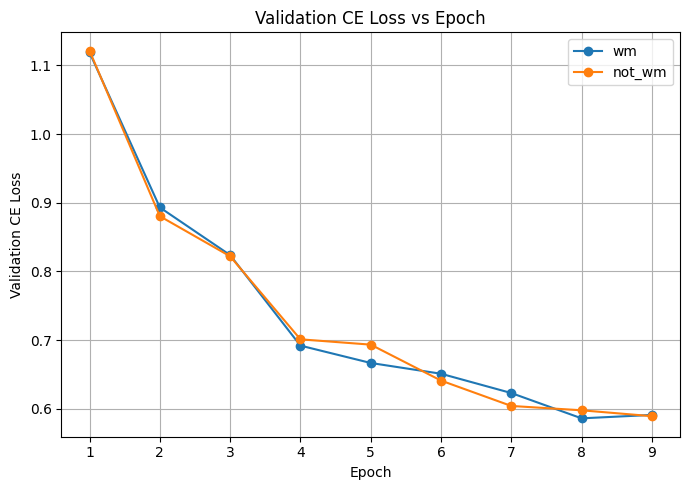

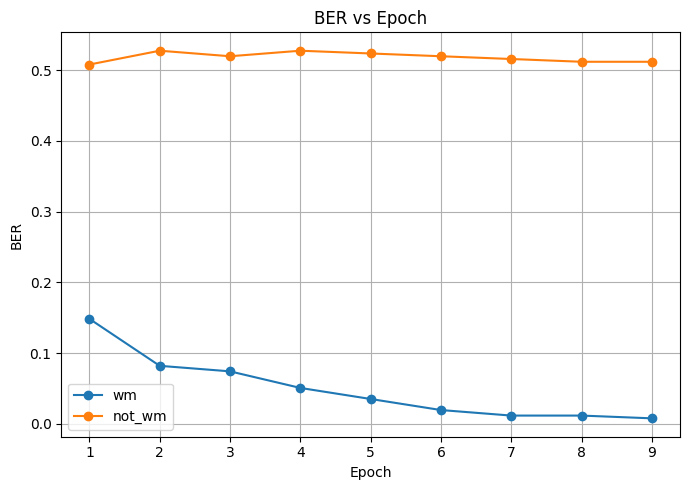

In [4]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Add as many experiment folders as you want here
base_dirs = [
    Path("drive/MyDrive/Security-Project/water_marked"),
    Path("drive/MyDrive/Security-Project/not_water_marked"),
]

# Optional custom labels for legend
labels = [
    "wm",
    "not_wm",
]

histories = []

for base_dir, label in zip(base_dirs, labels):
    hist_path = base_dir / "history.json"
    with open(hist_path, "r") as f:
        data = json.load(f)
    histories.append({
        "label": label,
        "data": data,
    })

def extract_metric(data, key):
    return [x["epoch"] for x in data], [x[key] for x in data]

def make_plot(histories, metric_key, title, ylabel):
    plt.figure(figsize=(7, 5))

    for exp in histories:
        epochs, values = extract_metric(exp["data"], metric_key)
        plt.plot(epochs, values, marker="o", label=exp["label"])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plots
make_plot(histories, "test_acc", "Test Accuracy vs Epoch", "Test Accuracy")
make_plot(histories, "train_ce_loss", "Train CE Loss vs Epoch", "Train CE Loss")
make_plot(histories, "val_ce_loss", "Validation CE Loss vs Epoch", "Validation CE Loss")
make_plot(histories, "ber", "BER vs Epoch", "BER")